# Title :- Data Profiler

## Part B : Data Acquisition

In [1]:
import pandas as pd

### 5. Import datasets from diffrent sources:

In [2]:
# load csv file using pandas
df_csv=pd.read_csv("C:\\Users\\ansh\\OneDrive\\Desktop\\Ansh\\rw\\rw\\DPFE\\pr1\\customer_data.csv")

In [3]:
# parse a json file
import json
with open("C:\\Users\\ansh\\OneDrive\\Desktop\\Ansh\\rw\\rw\\DPFE\\pr1\\customer_extra.json") as f:
    data = json.load(f)

print(data)

[{'CustomerID': 1001, 'PreferredPayment': 'UPI', 'Membership': 'Bronze', 'LastLogin': '2026-07-11'}, {'CustomerID': 1002, 'PreferredPayment': 'UPI', 'Membership': 'Gold', 'LastLogin': '2026-07-03'}, {'CustomerID': 1003, 'PreferredPayment': 'Cash', 'Membership': 'Gold', 'LastLogin': '2026-07-04'}, {'CustomerID': 1004, 'PreferredPayment': 'UPI', 'Membership': 'Bronze', 'LastLogin': '2026-07-13'}, {'CustomerID': 1005, 'PreferredPayment': 'NetBanking', 'Membership': 'Bronze', 'LastLogin': '2026-07-10'}, {'CustomerID': 1006, 'PreferredPayment': 'Card', 'Membership': 'Bronze', 'LastLogin': '2026-07-07'}, {'CustomerID': 1007, 'PreferredPayment': 'NetBanking', 'Membership': 'Silver', 'LastLogin': '2026-07-05'}, {'CustomerID': 1008, 'PreferredPayment': 'NetBanking', 'Membership': 'Silver', 'LastLogin': '2026-07-10'}, {'CustomerID': 1009, 'PreferredPayment': 'UPI', 'Membership': 'Bronze', 'LastLogin': '2026-07-12'}, {'CustomerID': 1010, 'PreferredPayment': 'UPI', 'Membership': 'Gold', 'LastLogin

In [4]:
# connect to a sql table and fetch records
import sqlite3

conn = sqlite3.connect("C:\\Users\\ansh\\OneDrive\\Desktop\\Ansh\\rw\\rw\\DPFE\\pr1\\customer_orders.db")
df_sql = pd.read_sql("SELECT * FROM customer_orders", conn)
print(df_sql)

     OrderID  CustomerID     Product   Amount   OrderDate
0          1        1001       Phone  2413.52  2026-03-07
1          2        1001    Keyboard  1425.57  2026-01-03
2          3        1001    Keyboard  4525.81  2026-06-23
3          4        1002      Laptop  2320.30  2026-03-30
4          5        1002       Mouse  1635.94  2026-04-19
..       ...         ...         ...      ...         ...
337      338        1099    Keyboard  3333.89  2026-05-02
338      339        1099    Keyboard  3322.59  2026-03-15
339      340        1099  Headphones  1569.99  2026-01-16
340      341        1100       Mouse  1314.66  2026-01-10
341      342        1100       Phone  2205.85  2026-02-15

[342 rows x 5 columns]


In [5]:
# fetch data from an API
import requests
response = requests.get("https://dummyjson.com/users")
response_data = response.json()
print(response_data)

{'users': [{'id': 1, 'firstName': 'Emily', 'lastName': 'Johnson', 'maidenName': 'Smith', 'age': 29, 'gender': 'female', 'email': 'emily.johnson@x.dummyjson.com', 'phone': '+81 965-431-3024', 'username': 'emilys', 'password': 'emilyspass', 'birthDate': '1996-5-30', 'image': 'https://dummyjson.com/icon/emilys/128', 'bloodGroup': 'O-', 'height': 193.24, 'weight': 63.16, 'eyeColor': 'Green', 'hair': {'color': 'Brown', 'type': 'Curly'}, 'ip': '42.48.100.32', 'address': {'address': '626 Main Street', 'city': 'Phoenix', 'state': 'Mississippi', 'stateCode': 'MS', 'postalCode': '29112', 'coordinates': {'lat': -77.16213, 'lng': -92.084824}, 'country': 'United States'}, 'macAddress': '47:fa:41:18:ec:eb', 'university': 'University of Wisconsin--Madison', 'bank': {'cardExpire': '05/28', 'cardNumber': '3693233511855044', 'cardType': 'Diners Club International', 'currency': 'GBP', 'iban': 'GB74MH2UZLR9TRPHYNU8F8'}, 'company': {'department': 'Engineering', 'name': 'Dooley, Kozey and Cronin', 'title': 

## Part C : Data Understanding & Cleaning

### 6. Perform initial exploration:

In [6]:
# use .head() , .info() and .describe() to explore.
df_csv.head()

,CustomerID,Name,Age,Gender,Income,City,Purchases,Churn
0,1001,Customer_1001,58.0,Female,NaN,Surat,18,0
1,1002,Customer_1002,24.0,F,NaN,Ahmedabad,28,0
2,1003,Customer_1003,32.0,F,NaN,Surat,13,1
3,1004,Customer_1004,35.0,Female,NaN,Vadodara,28,1
4,1005,Customer_1005,39.0,M,NaN,Vadodara,7,1


In [7]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  101 non-null    int64  
 1   Name        101 non-null    object 
 2   Age         96 non-null     float64
 3   Gender      101 non-null    object 
 4   Income      43 non-null     float64
 5   City        101 non-null    object 
 6   Purchases   101 non-null    int64  
 7   Churn       101 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 6.4+ KB


In [8]:
df_csv.describe()

,CustomerID,Age,Income,Purchases,Churn
count,101.000000,96.000000,43.000000,101.000000,101.000000
mean,1050.059406,39.864583,73363.023256,21.653465,0.485149
std,29.203706,12.261725,31339.230753,11.026727,0.502272
min,1001.000000,19.000000,20074.000000,1.000000,0.000000
25%,1025.000000,30.000000,42816.000000,13.000000,0.000000
50%,1050.000000,39.000000,72581.000000,22.000000,0.000000
75%,1075.000000,51.000000,103932.500000,30.000000,1.000000
max,1100.000000,60.000000,118366.000000,40.000000,1.000000


In [9]:
# identify missing values and duplicates
missing_values = df_csv.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 CustomerID     0
Name           0
Age            5
Gender         0
Income        58
City           0
Purchases      0
Churn          0
dtype: int64


In [10]:
duplicates = df_csv.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 1


### 7. Apply data cleaning:

In [11]:
# Handle missing values 
df_csv['Age'].fillna(df_csv['Age'].mean(), inplace=True)
df_csv['Income'].fillna(df_csv['Income'].median(), inplace=True)

C:\Users\ansh\AppData\Local\Temp\ipykernel_13228\616415727.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_csv['Age'].fillna(df_csv['Age'].mean(), inplace=True)
C:\Users\ansh\AppData\Local\Temp\ipykernel_13228\616415727.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [12]:
# remove duplicates
df_csv.drop_duplicates(inplace=True)

## Part D : Exploratory Data Analysis(EDA)

### 8. Perform Univariate Analysis

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

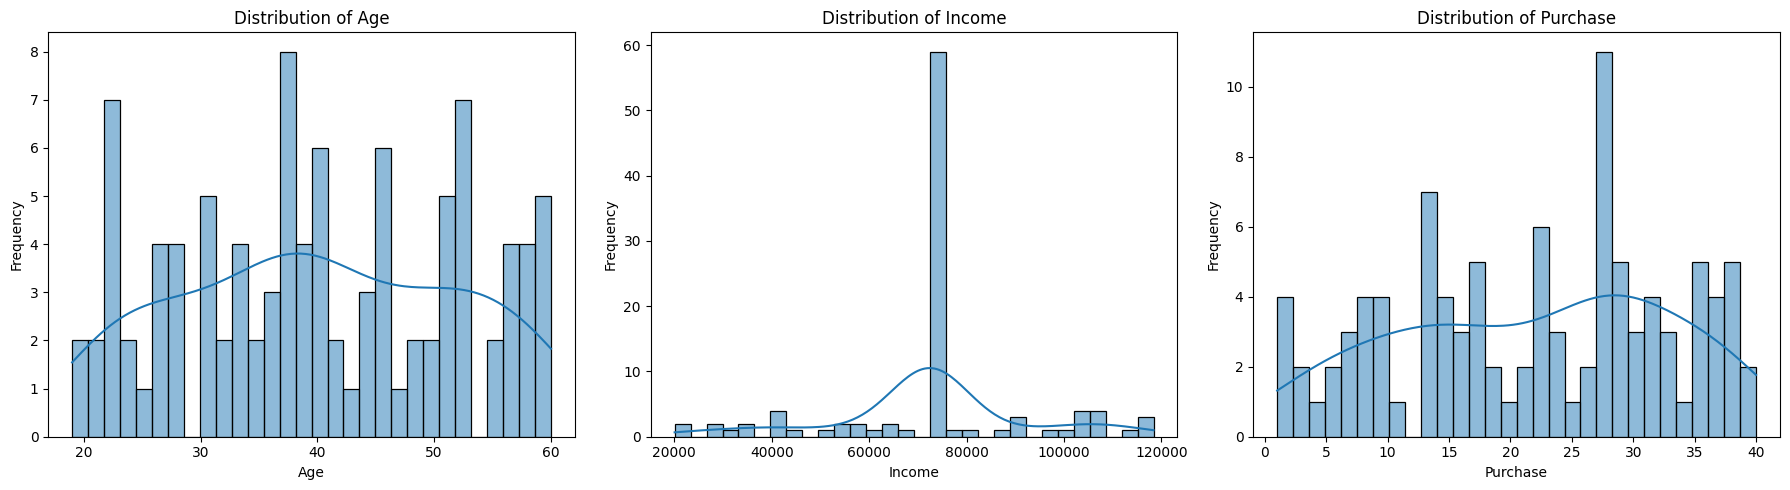

In [34]:
# distribution plot of Age , Income and Purchase

fig , ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_csv['Age'], bins=30, kde=True,ax=ax[0])
ax[0].set_title('Distribution of Age')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Frequency')

sns.histplot(df_csv['Income'], bins=30, kde=True,ax=ax[1])
ax[1].set_title('Distribution of Income')
ax[1].set_xlabel('Income')
ax[1].set_ylabel('Frequency')

sns.histplot(df_csv['Purchases'], bins=30, kde=True,ax=ax[2])
ax[2].set_title('Distribution of Purchase')
ax[2].set_xlabel('Purchase')
ax[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 9. Perform Bivariate Analysis

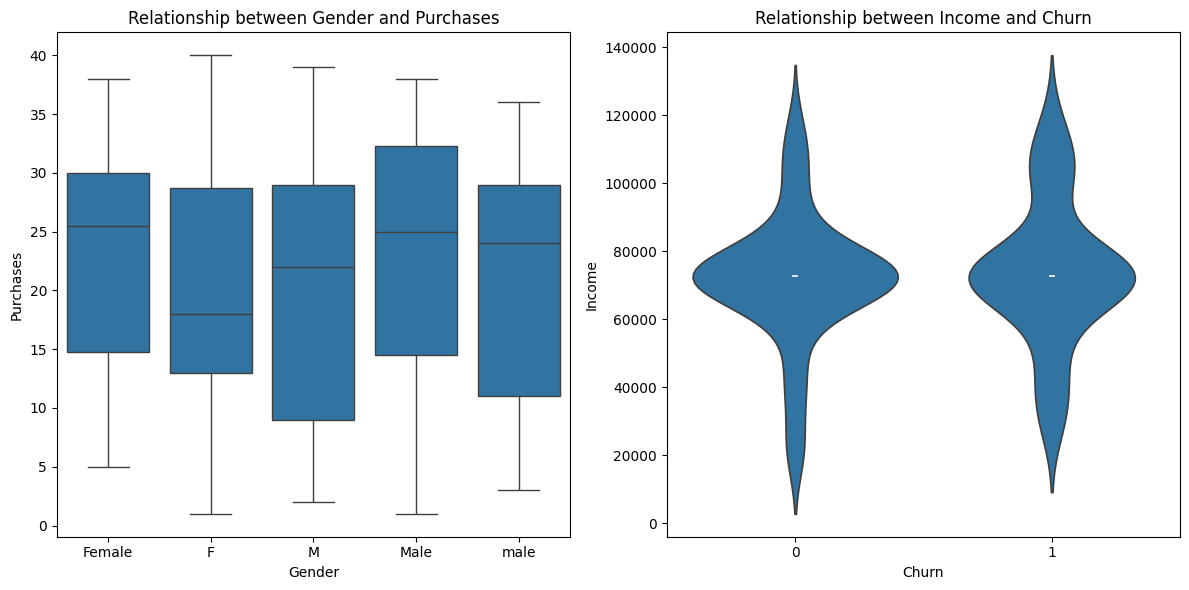

In [42]:
# Relationship between Gender and Purchases 

fig,ax = plt.subplots(1,2,figsize=(12, 6))
sns.boxplot(data=df_csv, x='Gender', y='Purchases', ax=ax[0])
ax[0].set_title('Relationship between Gender and Purchases')
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Purchases')

# Relationship between Income and Churn
sns.violinplot(data=df_csv, x='Churn', y='Income', ax=ax[1])
ax[1].set_title('Relationship between Income and Churn')
ax[1].set_xlabel('Churn')
ax[1].set_ylabel('Income')


plt.tight_layout()
plt.show()

### 10. Perform Multivariate Analysis

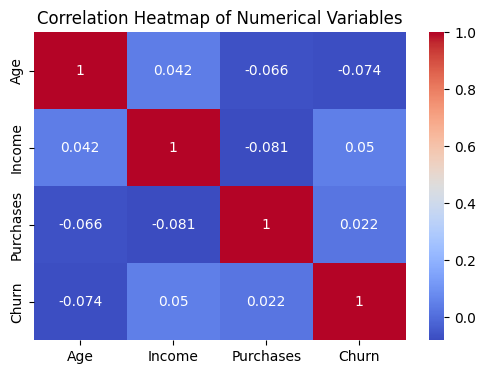

In [50]:
# Corelation heatmap of all numerical Variables
plt.figure(figsize=(6, 4))
sns.heatmap(df_csv[['Age', 'Income', 'Purchases', 'Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

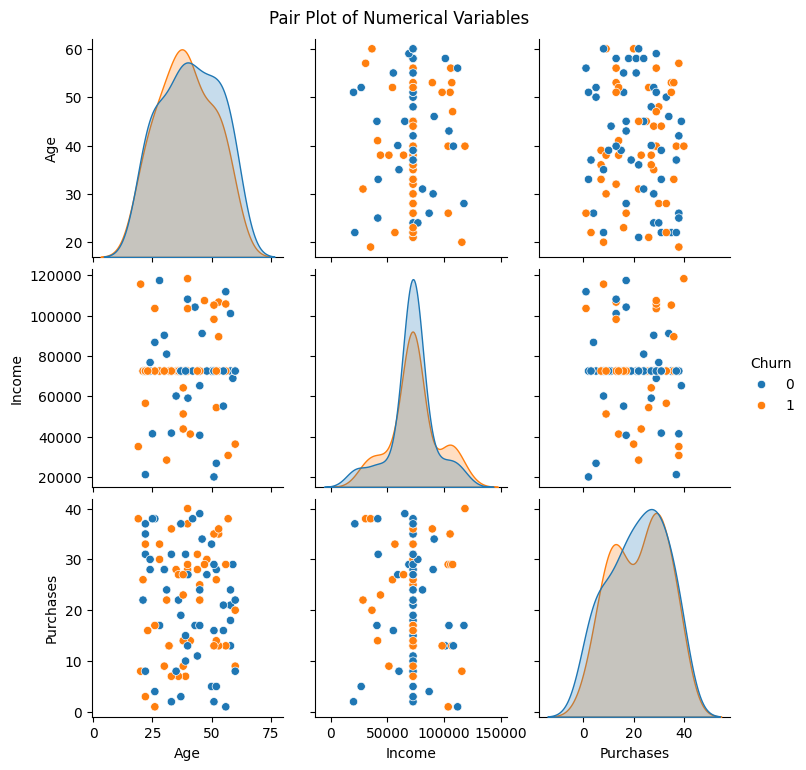

In [48]:
sns.pairplot(
    df_csv[['Age','Income','Purchases','Churn']],
    hue='Churn'
)

plt.suptitle("Pair Plot of Numerical Variables", y=1.02)
plt.show()

## Part E: Data Profiling

### 11. Generate a Pandas Profiling Report that summarizes:

In [53]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_csv, title="Data Profiling Report")
profile.to_file("C:\\Users\\ansh\\OneDrive\\Desktop\\Ansh\\rw\\rw\\DPFE\\pr1\\data_profiling_report.html")

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 206.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]